# Logistic Regression Model on Personal Transactions Data

Alisa Crowe

CS 549, Spring 2026

## Imports & Data Loading

In [24]:
import sys

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split

In [26]:
sys.path.insert(0, "../data")
from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)


train: (8644, 12) (8644,)
test:  (2162, 12) (2162,)


In [5]:
y_train.value_counts()

Category_Label
0    3056
1    2980
3    1864
2     538
4     206
Name: count, dtype: int64

## Baseline Model Training & Evaluation
### Baseline Model (No class weighting)

In [5]:
# define logistic regression model
clf1 = LogisticRegression(max_iter=2000)


In [6]:
# fit on training data
clf1.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
# evaluate on test data
y_pred = clf1.predict(X_test)

# print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.3658649398704903
Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.56      0.44       764
           1       0.36      0.48      0.41       745
           2       0.88      0.05      0.10       135
           3       0.00      0.00      0.00       466
           4       0.00      0.00      0.00        52

    accuracy                           0.37      2162
   macro avg       0.32      0.22      0.19      2162
weighted avg       0.31      0.37      0.30      2162



/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [8]:
# classes 3 and 4 are not being predicted at all
np.unique(y_pred, return_counts=True)

(array([0, 1, 2]), array([1165,  989,    8]))

### Baseline Model (Balanced classes)

In [10]:
clf2 = LogisticRegression(max_iter=2000, class_weight='balanced')

In [11]:
clf2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [12]:
y_pred = clf2.predict(X_test)

# print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.21137835337650324
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.32      0.33       764
           1       0.36      0.13      0.19       745
           2       0.08      0.22      0.11       135
           3       0.22      0.18      0.19       466
           4       0.02      0.13      0.03        52

    accuracy                           0.21      2162
   macro avg       0.20      0.20      0.17      2162
weighted avg       0.30      0.21      0.23      2162



In [13]:
np.unique(y_pred, return_counts=True)

(array([0, 1, 2, 3, 4]), array([684, 271, 399, 376, 432]))

## Hyperparamter Tuning

### Regularization Selection with No Class Weighting

Training with C = 0.001
CV Acc: 0.3689, CV F1: 0.1985
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3681, CV F1: 0.1988
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3670, CV F1: 0.1983
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3663, CV F1: 0.1980
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3661, CV F1: 0.1969
--------------------------------------------------
Training with C = 1
CV Acc: 0.3657, CV F1: 0.1966
--------------------------------------------------
Training with C = 5
CV Acc: 0.3659, CV F1: 0.1967
--------------------------------------------------
Training with C = 10
CV Acc: 0.3659, CV F1: 0.1968
--------------------------------------------------
Training with C = 20
CV Acc: 0.3657, CV F1: 0.1966
--------------------------------------------------


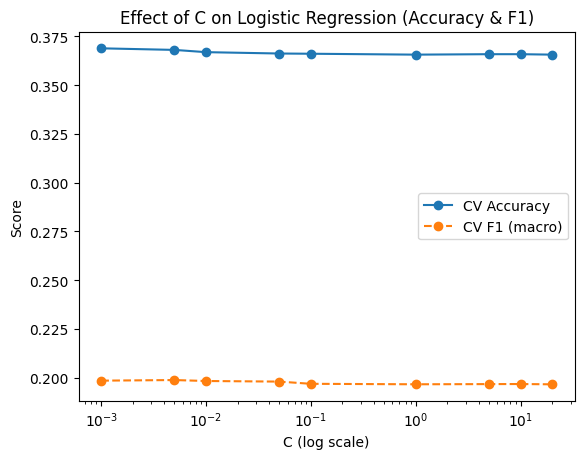

In [15]:
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10, 20]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

### Regularization Selection with Balanced Classes

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.2185, CV F1: 0.1851
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.2155, CV F1: 0.1828
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.2118, CV F1: 0.1800
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.2034, CV F1: 0.1733
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.2020, CV F1: 0.1715
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.2013, CV F1: 0.1705
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.2013, CV F1: 0.1703
--------------------------------------------------
Training with C = 10 (Balanced Classes)
CV Acc: 0.2009, CV F1: 0.1701
--------------------------------------------------
Training with C = 20 (B

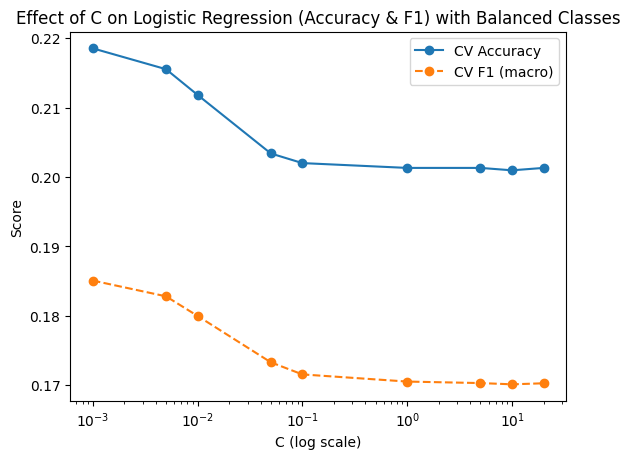

In [17]:
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10, 20]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced')
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()

### Hyperparameter Tuning: L1 vs L2 Regularization


=== Penalty = 0, Class Weight = None ===
Training with C = 0.001
CV Acc: 0.3686, CV F1: 0.1984
Test Acc: 0.3747, Test F1: 0.1937
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3680, CV F1: 0.1988
Test Acc: 0.3677, Test F1: 0.1913
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3668, CV F1: 0.1983
Test Acc: 0.3668, Test F1: 0.1908
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3665, CV F1: 0.1981
Test Acc: 0.3668, Test F1: 0.1909
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3668, CV F1: 0.1972
Test Acc: 0.3663, Test F1: 0.1906
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3664, CV F1: 0.1970
Test Acc: 0.3659, Test F1: 0.1904
--------------------------------------------------
Training with C = 5


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3661, CV F1: 0.1969
Test Acc: 0.3663, Test F1: 0.1906
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3660, CV F1: 0.1968
Test Acc: 0.3663, Test F1: 0.1906
--------------------------------------------------
Training with C = 20


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3660, CV F1: 0.1968
Test Acc: 0.3663, Test F1: 0.1906
--------------------------------------------------

=== Penalty = 1, Class Weight = None ===
Training with C = 0.001
CV Acc: 0.3535, CV F1: 0.1045
Test Acc: 0.3534, Test F1: 0.1044
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3561, CV F1: 0.1202
Test Acc: 0.3562, Test F1: 0.1242
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3685, CV F1: 0.1799
Test Acc: 0.3719, Test F1: 0.1813
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3641, CV F1: 0.1969
Test Acc: 0.3649, Test F1: 0.1897
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3664, CV F1: 0.1980
Test Acc: 0.3668, Test F1: 0.1907
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3652, CV F1: 0.1964
Test Acc: 0.3645, Test F1: 0.1897
--------------------------------------------------
Training with C = 5


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3659, CV F1: 0.1967
Test Acc: 0.3663, Test F1: 0.1906
--------------------------------------------------
Training with C = 10
CV Acc: 0.3659, CV F1: 0.1967
Test Acc: 0.3659, Test F1: 0.1904
--------------------------------------------------
Training with C = 20


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3659, CV F1: 0.1967
Test Acc: 0.3659, Test F1: 0.1904
--------------------------------------------------

=== Penalty = 0, Class Weight = Balanced ===
Training with C = 0.001
CV Acc: 0.2183, CV F1: 0.1847
Test Acc: 0.2105, Test F1: 0.1747
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.2158, CV F1: 0.1828
Test Acc: 0.2123, Test F1: 0.1763
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.2123, CV F1: 0.1801
Test Acc: 0.2123, Test F1: 0.1748
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.2035, CV F1: 0.1733
Test Acc: 0.2123, Test F1: 0.1734
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.2011, CV F1: 0.1707
Test Acc: 0.2132, Test F1: 0.1739
--------------------------------------------------
Training with C = 1
CV Acc: 0.2014, CV F1: 0.1706
Test Acc: 0.2105, Test F1: 0.1710
--------------------------------------------------
Training with

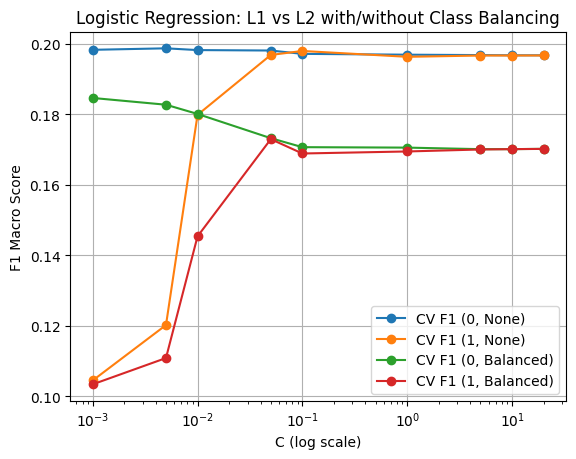


===== Class balance = None =====

0
CV Acc: [np.float64(0.3686), np.float64(0.368), np.float64(0.3668), np.float64(0.3665), np.float64(0.3668), np.float64(0.3664), np.float64(0.3661), np.float64(0.366), np.float64(0.366)]
CV F1 : [np.float64(0.1984), np.float64(0.1988), np.float64(0.1983), np.float64(0.1981), np.float64(0.1972), np.float64(0.197), np.float64(0.1969), np.float64(0.1968), np.float64(0.1968)]
Test Acc: [0.3747, 0.3677, 0.3668, 0.3668, 0.3663, 0.3659, 0.3663, 0.3663, 0.3663]
Test F1 : [0.1937, 0.1913, 0.1908, 0.1909, 0.1906, 0.1904, 0.1906, 0.1906, 0.1906]

1
CV Acc: [np.float64(0.3535), np.float64(0.3561), np.float64(0.3685), np.float64(0.3641), np.float64(0.3664), np.float64(0.3652), np.float64(0.3659), np.float64(0.3659), np.float64(0.3659)]
CV F1 : [np.float64(0.1045), np.float64(0.1202), np.float64(0.1799), np.float64(0.1969), np.float64(0.198), np.float64(0.1964), np.float64(0.1967), np.float64(0.1967), np.float64(0.1967)]
Test Acc: [0.3534, 0.3562, 0.3719, 0.3649, 

In [19]:
# parameters to test
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10, 20]
l1_ratios = [0, 1] # 0 for l2, 1 for l1
class_weights = [None, 'balanced']

# store results
results = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results[cw_label] = {}

    for ratio in l1_ratios:
        label = ratio

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=2000,
                C=C,
                l1_ratio=ratio,
                class_weight=cw,
                solver='saga',
                random_state=42
            )

            # Cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # Train on full training set
            clf.fit(X_train, y_train)

            # Test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results:
    for label in results[cw_label]:
        plt.plot(
            C_values,
            results[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression: L1 vs L2 with/without Class Balancing')
plt.legend()
plt.grid(True)

plt.show()

# -------- Print Results --------
for cw_label in results:
    print(f"\n===== Class balance = {cw_label} =====")
    for label in results[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(x, 4) for x in results[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(x, 4) for x in results[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(x, 4) for x in results[cw_label][label]['test_acc']])
        print("Test F1 :", [round(x, 4) for x in results[cw_label][label]['test_f1']])

## Evaluation: Training Best Config for Each Model

In [7]:
models = {
    "Baseline Logistic Regression": LogisticRegression(
        C=0.001,
        penalty="l2",
        solver="lbfgs",
        class_weight=None,
        max_iter=2000,
        random_state=42
    ),
    
    "Balanced Logistic Regression": LogisticRegression(
        C=0.001,
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )
}

In [30]:
results = []

for name, model in models.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    
    results.append({
        "Model": name,
        "C": model.C,
        "Penalty": model.penalty,
        "Class Weight": model.class_weight,
        "Accuracy": acc,
        "Macro F1": macro_f1
    })
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.savefig(f"../figures/confusion_matrix_{name.replace(' ', '_')}.png", dpi=300)
    plt.close()

        # ===== Classification Report (pretty table image) =====
    report_dict = classification_report(
        y_test, y_pred, zero_division=0, output_dict=True
    )
    report_df = pd.DataFrame(report_dict).transpose()
    
    # Clean formatting
    report_df = report_df.rename(columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1-Score",
        "support": "Support"
    })
    
    report_df[["Precision", "Recall", "F1-Score"]] = report_df[
        ["Precision", "Recall", "F1-Score"]
    ].round(3)
    
    report_df["Support"] = report_df["Support"].astype(int)
    
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.axis("off")
    
    table = ax.table(
        cellText=report_df.values,
        colLabels=report_df.columns,
        rowLabels=report_df.index,
        cellLoc="center",
        rowLoc="center",
        loc="center"
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Style header and row labels
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.5)
    
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#EAEAEA")
    
        if col == -1:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#F5F5F5")
    
    plt.title(
        f"Classification Report - {name}",
        fontsize=14,
        fontweight="bold",
        pad=20
    )
    
    plt.tight_layout()
    plt.savefig(
        f"../figures/classification_report_{name.replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

results_df = pd.DataFrame(results)
results_df


Baseline Logistic Regression
Accuracy: 0.3747
Macro F1: 0.1937


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Balanced Logistic Regression
Accuracy: 0.2105
Macro F1: 0.1745


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Model,C,Penalty,Class Weight,Accuracy,Macro F1
0,Baseline Logistic Regression,0.001,l2,NaN,0.374653,0.193709
1,Balanced Logistic Regression,0.001,l2,balanced,0.210453,0.174476
